In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/cdeotte/otto-validation/test_labels.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/011.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/006.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/017.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/016.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/005.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/019.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/012.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/015.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/007.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/018.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/000.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/001.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/008.parqu

检查cuDF版本，因为共现矩阵要做self-merge，数据量很大，能在GPU上加速表格计算

In [11]:
import cudf
print(cudf.__version__)

26.02.01


In [12]:
!git clone https://github.com/nlztrk/OTTO-Multi-Objective-Recommender-System.git

Cloning into 'OTTO-Multi-Objective-Recommender-System'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 62 (delta 2), reused 0 (delta 0), pack-reused 56 (from 1)
Receiving objects: 100% (62/62), 122.20 KiB | 4.70 MiB/s, done.
Resolving deltas: 100% (38/38), done.


- os：处理目录、路径、创建文件
- glob:按通配符批量查找文件
- pandas:数据处理
- numpy:数组、随机采样、数值运算

In [13]:
import os
import glob
import pandas as pd
import numpy as np

In [14]:
!ls -lh /kaggle/input

total 8.0K
drwxr-xr-x 3 root root 4.0K Jun 29 07:52 datasets
drwxr-xr-x 3 root root 4.0K Jun 29 07:59 notebooks


In [15]:
!find /kaggle/input -maxdepth 3 -type d

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/cdeotte
/kaggle/input/datasets/cdeotte/otto-validation
/kaggle/input/notebooks
/kaggle/input/notebooks/ddddd77714
/kaggle/input/notebooks/ddddd77714/otto-book


In [16]:
print("当前 /kaggle/input 下的数据集：")
print(os.listdir("/kaggle/input"))

print("\n搜索 parquet / pqt 文件：")
files = sorted(glob.glob("/kaggle/input/**/*.parquet", recursive=True))
files += sorted(glob.glob("/kaggle/input/**/*.pqt", recursive=True))

print("找到文件数：", len(files))
print("前10个文件：")
for f in files[:10]:
    print(f)

当前 /kaggle/input 下的数据集：
['datasets', 'notebooks']

搜索 parquet / pqt 文件：
找到文件数： 121
前10个文件：
/kaggle/input/datasets/cdeotte/otto-validation/test_labels.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/000.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/001.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/002.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/003.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/004.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/005.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/006.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/007.parquet
/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/008.parquet


In [17]:
MODE = "kaggle"

readpath = "/kaggle/input/datasets/cdeotte/otto-validation/*_parquet/*"
files = sorted(glob.glob(readpath))

print(len(files))
print(files[:5])

120
['/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/000.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/001.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/002.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/003.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/004.parquet']


由于数据量比较大，截取前20个文件

In [18]:
files = files[:20]

In [ ]:
VER = 6

import pandas as pd, numpy as np
from tqdm.notebook import tqdm
# tqdm是进度条库，notebook模式下使用tqdm.notebook
import os, sys, pickle, glob, gc
from collections import Counter
# Counter是计数器，统计元素出现次数

In [ ]:
VER = 6
type_labels = {'clicks': 0, 'carts': 1, 'orders': 2}
# 把行为类型转换为数字，便于后续计算、压缩存储、行为加权

def read_file_to_cache(f):
    df = pd.read_parquet(f)
    df.ts = (df.ts / 1000).astype('int32')
    df['type'] = df['type'].map(type_labels).astype('int8')
    return df

# 把毫秒转化为秒，并转换为int32类型，节省内存

def read_file(f):
    return cudf.DataFrame(data_cache[f])
# 存储到GPU内存中，便于后续计算

data_cache = {}
for f in tqdm(files):
    data_cache[f] = read_file_to_cache(f)

READ_CT = 5
CHUNK = int(np.ceil(len(files) / 6))
# CHUNK是每次读取的文件数，分6次读取，避免一次性读取过多文件导致内存不足

print("cache loaded:", len(data_cache))
print("CHUNK:", CHUNK)

  0%|          | 0/20 [00:00<?, ?it/s]

cache loaded: 20
CHUNK: 4


In [ ]:
OUT = "/kaggle/working/covisit"
os.makedirs(OUT, exist_ok=True)

print(OUT)
# 创建输出目录

/kaggle/working/covisit


### carts-orders共现矩阵构造

In [ ]:
type_weight = {0: 1, 1: 5, 2: 4}

# 加购更能表示当前 session 的下一步意图
# OTTO 要预测后续 clicks、carts、orders。加购通常发生在购买前，是一个很强的中间信号。
# order 数据更稀疏
# 购买行为比点击、加购少很多。如果给 order 过高权重，可能会让少量购买共现关系影响过大。

DISK_PIECES = 16
SIZE = 1.86e6 / DISK_PIECES

for PART in range(DISK_PIECES):
    print()
    print("### DISK PART", PART + 1)

    tmp = None

    for j in range(6):
        a = j * CHUNK
        b = min((j + 1) * CHUNK, len(files))

        if a >= b:
            continue

        print(f"Processing files {a} thru {b-1} in groups of {READ_CT}...")

        tmp2 = None

        for k in range(a, b, READ_CT):
            df_list = [read_file(files[k])]

            for i in range(1, READ_CT):
                if k + i < b:
                    df_list.append(read_file(files[k + i]))

            df = cudf.concat(df_list, ignore_index=True, axis=0)

            # 按 session 和时间倒序排列
            df = df.sort_values(["session", "ts"], ascending=[True, False])

            # 每个 session 只保留最近 30 条行为
            df = df.reset_index(drop=True)
            df["n"] = df.groupby("session").cumcount()
            df = df.loc[df.n < 30].drop("n", axis=1)

            # self-merge，生成同一 session 内的商品对
            df = df.merge(df, on="session")

            # 只保留 24 小时内共现，且 aid_x != aid_y
            # 更接近同一次购物意图
            df = df.loc[
                ((df.ts_x - df.ts_y).abs() < 24 * 60 * 60)
                & (df.aid_x != df.aid_y)
            ]

            # 当前 PART 只处理一部分 aid_x，防止爆显存
            df = df.loc[
                (df.aid_x >= PART * SIZE)
                & (df.aid_x < (PART + 1) * SIZE)
            ]

            if len(df) == 0:
                print(k, ", empty", end=" | ")
                continue

            # 去除同一用户重复出现的相同商品对+行为类型记录
            df = df[
                ["session", "aid_x", "aid_y", "type_y"]
            ].drop_duplicates(["session", "aid_x", "aid_y", "type_y"])

# self-merge 后得到的是 aid_x -> aid_y 的 item-to-item 关系。由于最终要为 aid_x 召回候选 aid_y，所以权重应该由候选商品 aid_y 的行为类型决定。如果 aid_y 被加购或购买，说明它作为推荐结果的转化价值更强，因此保留 type_y 并用它映射行为权重。


            df["wgt"] = df.type_y.map(type_weight)
            df = df[["aid_x", "aid_y", "wgt"]]
            df.wgt = df.wgt.astype("float32")

            # 统计商品对总权重
            df = df.groupby(["aid_x", "aid_y"]).wgt.sum()

            if tmp2 is None:
                tmp2 = df
            else:
                tmp2 = tmp2.add(df, fill_value=0)

            print(k, ",", end=" ")

        print()

        if tmp2 is not None:
            if tmp is None:
                tmp = tmp2
            else:
                tmp = tmp.add(tmp2, fill_value=0)

        del tmp2
        gc.collect()

    if tmp is None:
        print("No data for PART", PART)
        continue

    # 每个 aid_x 保留权重最高的 Top50 aid_y
    tmp = tmp.reset_index()
    tmp = tmp.sort_values(["aid_x", "wgt"], ascending=[True, False])

    tmp = tmp.reset_index(drop=True)
    tmp["n"] = tmp.groupby("aid_x").aid_y.cumcount()
    tmp = tmp.loc[tmp.n < 50].drop("n", axis=1)

    save_path = f"{OUT}/{MODE}_top_50_carts_orders_v{VER}_{PART}.pqt"
    tmp.to_pandas().to_parquet(save_path)

    print("saved:", save_path)

    del tmp
    gc.collect()


### DISK PART 1
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_carts_orders_v6_0.pqt

### DISK PART 2
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_carts_orders_v6_1.pqt

### DISK PART 3
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_carts_orders_v

In [23]:
!ls -lh /kaggle/working/covisit

total 135M
-rw-r--r-- 1 root root 8.5M Jun 29 09:01 kaggle_top_50_carts_orders_v6_0.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_10.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:02 kaggle_top_50_carts_orders_v6_11.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_12.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_13.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_14.pqt
-rw-r--r-- 1 root root 8.2M Jun 29 09:02 kaggle_top_50_carts_orders_v6_15.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:01 kaggle_top_50_carts_orders_v6_1.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:01 kaggle_top_50_carts_orders_v6_2.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:02 kaggle_top_50_carts_orders_v6_3.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_4.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_5.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:02 kaggle_top_50_cart

### 构造buy2buy矩阵

In [ ]:
# =========================
# Buy2Buy Co-visitation Matrix
# =========================

DISK_PIECES = 4
SIZE = 1.86e6 / DISK_PIECES

for PART in range(DISK_PIECES):
    print()
    print("### BUY2BUY DISK PART", PART + 1)

    tmp = None

    for j in range(6):
        a = j * CHUNK
        b = min((j + 1) * CHUNK, len(files))

        if a >= b:
            continue

        print(f"Processing files {a} thru {b-1} in groups of {READ_CT}...")

        tmp2 = None

        for k in range(a, b, READ_CT):
            df_list = [read_file(files[k])]

            for i in range(1, READ_CT):
                if k + i < b:
                    df_list.append(read_file(files[k + i]))

            df = cudf.concat(df_list, ignore_index=True, axis=0)

            # buy2buy 只保留 carts 和 orders
            df = df.loc[df["type"].isin([1, 2])]

            if len(df) == 0:
                print(k, ", empty", end=" | ")
                continue

            # 按 session 和时间倒序
            df = df.sort_values(["session", "ts"], ascending=[True, False])

            # 每个 session 保留最近 30 条
            df = df.reset_index(drop=True)
            df["n"] = df.groupby("session").cumcount()
            df = df.loc[df.n < 30].drop("n", axis=1)

            # self-merge 生成商品对
            df = df.merge(df, on="session")

            # 只保留 14 天内共现，且 aid_x != aid_y
            df = df.loc[
                ((df.ts_x - df.ts_y).abs() < 14 * 24 * 60 * 60)
                & (df.aid_x != df.aid_y)
            ]


            df = df.loc[
                (df.aid_x >= PART * SIZE)
                & (df.aid_x < (PART + 1) * SIZE)
            ]

            if len(df) == 0:
                print(k, ", empty", end=" | ")
                continue

            df = df[
                ["session", "aid_x", "aid_y"]
            ].drop_duplicates(["session", "aid_x", "aid_y"])


# 加购和购买的权重都是1，但是时间范围改为14天，捕捉更长周期的购买关联

            df["wgt"] = 1
            df = df[["aid_x", "aid_y", "wgt"]]
            df.wgt = df.wgt.astype("float32")

            df = df.groupby(["aid_x", "aid_y"]).wgt.sum()

            if tmp2 is None:
                tmp2 = df
            else:
                tmp2 = tmp2.add(df, fill_value=0)

            print(k, ",", end=" ")

        print()

        if tmp2 is not None:
            if tmp is None:
                tmp = tmp2
            else:
                tmp = tmp.add(tmp2, fill_value=0)

        del tmp2
        gc.collect()

    if tmp is None:
        print("No data for PART", PART)
        continue

    # 每个 aid_x 保留 Top50 aid_y
    tmp = tmp.reset_index()
    tmp = tmp.sort_values(["aid_x", "wgt"], ascending=[True, False])

    tmp = tmp.reset_index(drop=True)
    tmp["n"] = tmp.groupby("aid_x").aid_y.cumcount()
    tmp = tmp.loc[tmp.n < 50].drop("n", axis=1)

    save_path = f"{OUT}/{MODE}_top_50_buy2buy_v{VER}_{PART}.pqt"
    tmp.to_pandas().to_parquet(save_path)

    print("saved:", save_path)

    del tmp
    gc.collect()


### BUY2BUY DISK PART 1
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_buy2buy_v6_0.pqt

### BUY2BUY DISK PART 2
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_buy2buy_v6_1.pqt

### BUY2BUY DISK PART 3
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_

In [25]:
!ls -lh /kaggle/working/covisit | grep buy2buy

-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_0.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_1.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_2.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_3.pqt


### 构造clicks共现矩阵

In [ ]:
# =========================
# Clicks Co-visitation Matrix
# =========================

DISK_PIECES = 16
SIZE = 1.86e6 / DISK_PIECES

for PART in range(DISK_PIECES):
    print()
    print("### CLICKS DISK PART", PART + 1)

    tmp = None

    for j in range(6):
        a = j * CHUNK
        b = min((j + 1) * CHUNK, len(files))

        if a >= b:
            continue

        print(f"Processing files {a} thru {b-1} in groups of {READ_CT}...")

        tmp2 = None

        for k in range(a, b, READ_CT):
            df_list = [read_file(files[k])]

            for i in range(1, READ_CT):
                if k + i < b:
                    df_list.append(read_file(files[k + i]))

            df = cudf.concat(df_list, ignore_index=True, axis=0)

            # 按 session 和时间倒序
            df = df.sort_values(["session", "ts"], ascending=[True, False])

            # 每个 session 保留最近 30 条
            df = df.reset_index(drop=True)
            df["n"] = df.groupby("session").cumcount()
            df = df.loc[df.n < 30].drop("n", axis=1)

            # self-merge 生成商品对
            df = df.merge(df, on="session")

            # 只保留 24 小时内共现，且 aid_x != aid_y
            df = df.loc[
                ((df.ts_x - df.ts_y).abs() < 24 * 60 * 60)
                & (df.aid_x != df.aid_y)
            ]

            # 当前 PART 只处理一部分 aid_x
            df = df.loc[
                (df.aid_x >= PART * SIZE)
                & (df.aid_x < (PART + 1) * SIZE)
            ]

            if len(df) == 0:
                print(k, ", empty", end=" | ")
                continue

            df = df[
                ["session", "aid_x", "aid_y", "ts_x"]
            ].drop_duplicates(["session", "aid_x", "aid_y"])

# 时间权重：越新的行为权重越高

            df["wgt"] = 1 + 3 * (df.ts_x - 1659304800) / (1662328791 - 1659304800)

            df = df[["aid_x", "aid_y", "wgt"]]
            df.wgt = df.wgt.astype("float32")

            df = df.groupby(["aid_x", "aid_y"]).wgt.sum()

            if tmp2 is None:
                tmp2 = df
            else:
                tmp2 = tmp2.add(df, fill_value=0)

            print(k, ",", end=" ")

        print()

        if tmp2 is not None:
            if tmp is None:
                tmp = tmp2
            else:
                tmp = tmp.add(tmp2, fill_value=0)

        del tmp2
        gc.collect()

    if tmp is None:
        print("No data for PART", PART)
        continue

    # 每个 aid_x 保留 Top50 aid_y
    tmp = tmp.reset_index()
    tmp = tmp.sort_values(["aid_x", "wgt"], ascending=[True, False])

    tmp = tmp.reset_index(drop=True)
    tmp["n"] = tmp.groupby("aid_x").aid_y.cumcount()
    tmp = tmp.loc[tmp.n < 50].drop("n", axis=1)

    save_path = f"{OUT}/{MODE}_top_50_clicks_v{VER}_{PART}.pqt"
    tmp.to_pandas().to_parquet(save_path)

    print("saved:", save_path)

    del tmp
    gc.collect()


### CLICKS DISK PART 1
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_clicks_v6_0.pqt

### CLICKS DISK PART 2
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_clicks_v6_1.pqt

### CLICKS DISK PART 3
Processing files 0 thru 3 in groups of 5...
0 , 
Processing files 4 thru 7 in groups of 5...
4 , 
Processing files 8 thru 11 in groups of 5...
8 , 
Processing files 12 thru 15 in groups of 5...
12 , 
Processing files 16 thru 19 in groups of 5...
16 , 
saved: /kaggle/working/covisit/kaggle_top_50_click

In [27]:
!ls -lh /kaggle/working/covisit | grep clicks

-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_0.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_10.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_11.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_12.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_13.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_14.pqt
-rw-r--r-- 1 root root 9.8M Jun 29 09:02 kaggle_top_50_clicks_v6_15.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_1.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_2.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_3.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_4.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_5.pqt
-rw-r--r-- 1 root root  10M Jun 29 09:02 kaggle_top_50_clicks_v6_6.pqt
-rw-r--r-- 1 root root  11M Jun 29 09:02 kaggle_top_50_clicks_v6_7.pqt


In [28]:
!ls -lh /kaggle/working/covisit

total 310M
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_0.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_1.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_2.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_3.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:01 kaggle_top_50_carts_orders_v6_0.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_10.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:02 kaggle_top_50_carts_orders_v6_11.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_12.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_13.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_14.pqt
-rw-r--r-- 1 root root 8.2M Jun 29 09:02 kaggle_top_50_carts_orders_v6_15.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:01 kaggle_top_50_carts_orders_v6_1.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:01 kaggle_top_50_carts_orders_v6_2.pqt
-r

In [29]:
import glob

print("carts_orders:", len(glob.glob("/kaggle/working/covisit/*carts_orders*.pqt")))
print("buy2buy:", len(glob.glob("/kaggle/working/covisit/*buy2buy*.pqt")))
print("clicks:", len(glob.glob("/kaggle/working/covisit/*clicks*.pqt")))

carts_orders: 16
buy2buy: 4
clicks: 16


## 01 

In [30]:
!find /kaggle/input -maxdepth 4 -type f | head -80

/kaggle/input/datasets/cdeotte/otto-validation/test_labels.parquet


In [ ]:
import os, glob, gc
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

ROOT = "/kaggle/input/datasets/cdeotte/otto-validation"
OUT_SPLIT = "/kaggle/working/splitted_raw_data"
os.makedirs(OUT_SPLIT, exist_ok=True)


# 切分后数据保存目录，历史训练行为日志、验证集session、验证集标签
TRAIN_FILES = sorted(glob.glob(f"{ROOT}/train_parquet/*"))
VAL_FILES = sorted(glob.glob(f"{ROOT}/test_parquet/*"))
LABEL_PATH = f"{ROOT}/test_labels.parquet"

print("train files:", len(TRAIN_FILES))
print("val files:", len(VAL_FILES))
print("label exists:", os.path.exists(LABEL_PATH))
print(TRAIN_FILES[:3])
print(VAL_FILES[:3])

train files: 100
val files: 20
label exists: True
['/kaggle/input/datasets/cdeotte/otto-validation/train_parquet/000.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/train_parquet/001.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/train_parquet/002.parquet']
['/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/000.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/001.parquet', '/kaggle/input/datasets/cdeotte/otto-validation/test_parquet/002.parquet']


In [ ]:
TRAIN_N = 20
VAL_N = 5
# 由于资源有限，只取部分数据
train_files = TRAIN_FILES[:TRAIN_N]
val_files = VAL_FILES[:VAL_N]

print("use train files:", len(train_files))
print("use val files:", len(val_files))

use train files: 20
use val files: 5


In [33]:
type_labels = {"clicks": 0, "carts": 1, "orders": 2}

def load_parquet_files(files):
    dfs = []
    for f in tqdm(files):
        df = pd.read_parquet(f)
        
        # ts 如果是毫秒就转成秒
        if df["ts"].max() > 10_000_000_000:
            df["ts"] = (df["ts"] / 1000).astype("int32")
        else:
            df["ts"] = df["ts"].astype("int32")
        
        # type 如果是字符串就映射成数字
        if df["type"].dtype == "object":
            df["type"] = df["type"].map(type_labels).astype("int8")
        else:
            df["type"] = df["type"].astype("int8")
        
        dfs.append(df)
    
    return pd.concat(dfs, ignore_index=True)

# 训练行为数据
train_df = load_parquet_files(train_files)
train_df.to_parquet(f"{OUT_SPLIT}/train.parquet")
print("saved train:", train_df.shape)

# 验证行为数据
val_df = load_parquet_files(val_files)
val_df.to_parquet(f"{OUT_SPLIT}/val.parquet")
print("saved val:", val_df.shape)

# 验证集真实标签，只保留当前 val_df 里的 session
val_labels_df = pd.read_parquet(LABEL_PATH)
val_sessions = set(val_df["session"].unique())
val_labels_df = val_labels_df[val_labels_df["session"].isin(val_sessions)]

val_labels_df.to_parquet(f"{OUT_SPLIT}/val_labels.parquet")
print("saved val_labels:", val_labels_df.shape)

# 保存一部分 val session，后续训练排序模型可能会用
np.random.seed(1337)
valid_sessions = val_df["session"].unique()

sample_size = max(1, len(valid_sessions) // 2)
val_sessions_for_train = np.random.choice(valid_sessions, sample_size, replace=False)

np.save(f"{OUT_SPLIT}/val_sessions_for_train.npy", val_sessions_for_train)
print("saved val_sessions_for_train:", len(val_sessions_for_train))

  0%|          | 0/20 [00:00<?, ?it/s]

saved train: (60143610, 4)


  0%|          | 0/5 [00:00<?, ?it/s]

saved val: (2083044, 4)
saved val_labels: (559623, 3)
saved val_sessions_for_train: 225157


In [34]:
!ls -lh /kaggle/working/splitted_raw_data

total 493M
-rw-r--r-- 1 root root 468M Jun 29 09:03 train.parquet
-rw-r--r-- 1 root root 7.6M Jun 29 09:03 val_labels.parquet
-rw-r--r-- 1 root root  18M Jun 29 09:03 val.parquet
-rw-r--r-- 1 root root 880K Jun 29 09:03 val_sessions_for_train.npy


## 02 候选商品生成

In [35]:
import glob, os

print("carts_orders:", len(glob.glob("/kaggle/working/covisit/*carts_orders*.pqt")))
print("buy2buy:", len(glob.glob("/kaggle/working/covisit/*buy2buy*.pqt")))
print("clicks:", len(glob.glob("/kaggle/working/covisit/*clicks*.pqt")))

!ls -lh /kaggle/working/covisit | head

carts_orders: 16
buy2buy: 4
clicks: 16
total 310M
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_0.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_1.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_2.pqt
-rw-r--r-- 1 root root 3.9M Jun 29 09:02 kaggle_top_50_buy2buy_v6_3.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:01 kaggle_top_50_carts_orders_v6_0.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_10.pqt
-rw-r--r-- 1 root root 8.4M Jun 29 09:02 kaggle_top_50_carts_orders_v6_11.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_12.pqt
-rw-r--r-- 1 root root 8.5M Jun 29 09:02 kaggle_top_50_carts_orders_v6_13.pqt


In [36]:
import os, glob, gc, itertools
from collections import Counter

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

VER = 6

SPLIT_DIR = "/kaggle/working/splitted_raw_data"
COVISIT_DIR = "/kaggle/working/covisit"
OUT_CAND = "/kaggle/working/candidate_data"
os.makedirs(OUT_CAND, exist_ok=True)

# 你前面生成的是 top_50 文件，但最终每个 session 可以生成 100 个候选
COVISIT_TOP = 50
CANDIDATE_COUNT = 100

target_df = pd.read_parquet(f"{SPLIT_DIR}/val.parquet")
print(target_df.shape)
target_df.head()

(2083044, 4)


,session,aid,ts,type
0,11098528,11830,1661119200,0
1,11098529,1105029,1661119200,0
2,11098530,264500,1661119200,0
3,11098530,264500,1661119288,0
4,11098530,409236,1661119369,0


In [ ]:
# 把共现矩阵转成字典
def pqt_to_dict(df):
    return df.groupby("aid_x").aid_y.apply(list).to_dict()

def load_covisit_dict(pattern):
    files = sorted(glob.glob(pattern))
    print(pattern, "num_files:", len(files))
    
    result = {}
    for f in tqdm(files):
        result.update(pqt_to_dict(pd.read_parquet(f)))
    return result

top_20_clicks = load_covisit_dict(
    f"{COVISIT_DIR}/kaggle_top_{COVISIT_TOP}_clicks_v{VER}_*.pqt"
)

top_20_buys = load_covisit_dict(
    f"{COVISIT_DIR}/kaggle_top_{COVISIT_TOP}_carts_orders_v{VER}_*.pqt"
)

top_20_buy2buy = load_covisit_dict(
    f"{COVISIT_DIR}/kaggle_top_{COVISIT_TOP}_buy2buy_v{VER}_*.pqt"
)

print("co-visitation matrix sizes:")
print("clicks:", len(top_20_clicks))
print("carts_orders:", len(top_20_buys))
print("buy2buy:", len(top_20_buy2buy))

/kaggle/working/covisit/kaggle_top_50_clicks_v6_*.pqt num_files: 16


  0%|          | 0/16 [00:00<?, ?it/s]

/kaggle/working/covisit/kaggle_top_50_carts_orders_v6_*.pqt num_files: 16


  0%|          | 0/16 [00:00<?, ?it/s]

/kaggle/working/covisit/kaggle_top_50_buy2buy_v6_*.pqt num_files: 4


  0%|          | 0/4 [00:00<?, ?it/s]

co-visitation matrix sizes:
clicks: 771519
carts_orders: 771519
buy2buy: 190301


### 全局热门商品兜底

In [38]:
top_clicks = target_df.loc[target_df["type"] == 0, "aid"].value_counts().index.values[:CANDIDATE_COUNT]
top_carts = target_df.loc[target_df["type"] == 1, "aid"].value_counts().index.values[:CANDIDATE_COUNT]
top_orders = target_df.loc[target_df["type"] == 2, "aid"].value_counts().index.values[:CANDIDATE_COUNT]

print(len(top_clicks), len(top_carts), len(top_orders))

100 100 100


In [ ]:
type_weight_multipliers = {0: 1, 1: 5, 2: 4}

# 给每个session生成clicks候选
def suggest_clicks(df):
    aids = df.aid.tolist()
    types = df.type.tolist()
    
    # 最近出现的商品排前面，去重
    unique_aids = list(dict.fromkeys(aids[::-1]))
    
    # 如果 session 里商品已经很多，就直接基于历史商品重排
    if len(unique_aids) >= CANDIDATE_COUNT:
        weights = np.logspace(0.1, 1, len(aids), base=2, endpoint=True) - 1
        # 每个商品的分数=时间权重×行为类型权重
        aids_temp = Counter()
        
        for aid, w, t in zip(aids, weights, types):
            aids_temp[aid] += w * type_weight_multipliers[t]
        
        sorted_aids = [k for k, v in aids_temp.most_common(CANDIDATE_COUNT)]
        return sorted_aids
    
    # 用 clicks 共现矩阵召回
    aids2 = list(itertools.chain(*[
        top_20_clicks[aid] for aid in unique_aids if aid in top_20_clicks
    ]))
    
# 统计共现候选出现次数，越多约相关
    top_aids2 = [
        aid2 for aid2, cnt in Counter(aids2).most_common(CANDIDATE_COUNT)
        if aid2 not in unique_aids
    ]
    
    result = unique_aids + top_aids2[:CANDIDATE_COUNT - len(unique_aids)]
    
    # 用热门点击商品兜底补齐
    return result + list(top_clicks)[:CANDIDATE_COUNT - len(result)]


# 给每个session生成carts候选
def suggest_carts(df):
    aids = df.aid.tolist()
    types = df.type.tolist()
    
    unique_aids = list(dict.fromkeys(aids[::-1]))
    
    # carts 目标：使用 click/cart 历史行为
    df_buy = df.loc[(df["type"] == 0) | (df["type"] == 1)]
    unique_buys = list(dict.fromkeys(df_buy.aid.tolist()[::-1]))
    
    if len(unique_aids) >= CANDIDATE_COUNT:
        weights = np.logspace(0.5, 1, len(aids), base=2, endpoint=True) - 1
        aids_temp = Counter()
        
        for aid, w, t in zip(aids, weights, types):
            aids_temp[aid] += w * type_weight_multipliers[t]
        
        aids2 = list(itertools.chain(*[
            top_20_buys[aid] for aid in unique_buys if aid in top_20_buys
        ]))
        
        for aid in aids2:
            aids_temp[aid] += 0.1
        
        sorted_aids = [k for k, v in aids_temp.most_common(CANDIDATE_COUNT)]
        return sorted_aids
    
    # 同时使用 clicks 共现和 carts_orders 共现
    aids1 = list(itertools.chain(*[
        top_20_clicks[aid] for aid in unique_aids if aid in top_20_clicks
    ]))
    
    aids2 = list(itertools.chain(*[
        top_20_buys[aid] for aid in unique_aids if aid in top_20_buys
    ]))
    
    top_aids2 = [
        aid2 for aid2, cnt in Counter(aids1 + aids2).most_common(CANDIDATE_COUNT)
        if aid2 not in unique_aids
    ]
    
    result = unique_aids + top_aids2[:CANDIDATE_COUNT - len(unique_aids)]
    
    return result + list(top_carts)[:CANDIDATE_COUNT - len(result)]

# 生成orders候选
def suggest_buys(df):
    aids = df.aid.tolist()
    types = df.type.tolist()
    
    unique_aids = list(dict.fromkeys(aids[::-1]))
    
    # orders 目标：更关注 carts / orders 历史行为
    df_buy = df.loc[(df["type"] == 1) | (df["type"] == 2)]
    unique_buys = list(dict.fromkeys(df_buy.aid.tolist()[::-1]))
    
    if len(unique_aids) >= CANDIDATE_COUNT:
        weights = np.logspace(0.5, 1, len(aids), base=2, endpoint=True) - 1
        aids_temp = Counter()
        
        for aid, w, t in zip(aids, weights, types):
            aids_temp[aid] += w * type_weight_multipliers[t]
        
        aids3 = list(itertools.chain(*[
            top_20_buy2buy[aid] for aid in unique_buys if aid in top_20_buy2buy
        ]))
        
        for aid in aids3:
            aids_temp[aid] += 0.1
        
        sorted_aids = [k for k, v in aids_temp.most_common(CANDIDATE_COUNT)]
        return sorted_aids
    
    aids2 = list(itertools.chain(*[
        top_20_buys[aid] for aid in unique_aids if aid in top_20_buys
    ]))
    
    aids3 = list(itertools.chain(*[
        top_20_buy2buy[aid] for aid in unique_buys if aid in top_20_buy2buy
    ]))
    
    top_aids2 = [
        aid2 for aid2, cnt in Counter(aids2 + aids3).most_common(CANDIDATE_COUNT)
        if aid2 not in unique_aids
    ]
    
    result = unique_aids + top_aids2[:CANDIDATE_COUNT - len(unique_aids)]
    
    return result + list(top_orders)[:CANDIDATE_COUNT - len(result)]

In [40]:
try:
    from pandarallel import pandarallel
except ImportError:
    !pip install -q pandarallel
    from pandarallel import pandarallel

pandarallel.initialize(
    progress_bar=True,
    nb_workers=4,
    use_memory_fs=False
)

  Preparing metadata (setup.py) ... done
INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [41]:
target_df = target_df.sort_values(["session", "ts"]).reset_index(drop=True)

print("target_df shape:", target_df.shape)
print("num sessions:", target_df["session"].nunique())
target_df.head()

target_df shape: (2083044, 4)
num sessions: 450315


,session,aid,ts,type
0,11098528,11830,1661119200,0
1,11098529,1105029,1661119200,0
2,11098530,264500,1661119200,0
3,11098530,264500,1661119288,0
4,11098530,409236,1661119369,0


In [42]:
pred_df_clicks = target_df.groupby("session", sort=False).parallel_apply(suggest_clicks)

print("clicks candidates done")

clicks candidates done


In [43]:
pred_df_carts = target_df.groupby("session", sort=False).parallel_apply(suggest_carts)

print("carts candidates done")

carts candidates done


In [44]:
pred_df_buys = target_df.groupby("session", sort=False).parallel_apply(suggest_buys)

print("orders candidates done")

orders candidates done


In [45]:
clicks_pred_df = pd.DataFrame(pred_df_clicks, columns=["aid"]).reset_index()
carts_pred_df = pd.DataFrame(pred_df_carts, columns=["aid"]).reset_index()
orders_pred_df = pd.DataFrame(pred_df_buys, columns=["aid"]).reset_index()

clicks_candidates = clicks_pred_df.explode("aid").reset_index(drop=True)
carts_candidates = carts_pred_df.explode("aid").reset_index(drop=True)
orders_candidates = orders_pred_df.explode("aid").reset_index(drop=True)

clicks_candidates.to_parquet(f"{OUT_CAND}/local_{CANDIDATE_COUNT}candidates_clicks.parquet")
carts_candidates.to_parquet(f"{OUT_CAND}/local_{CANDIDATE_COUNT}candidates_carts.parquet")
orders_candidates.to_parquet(f"{OUT_CAND}/local_{CANDIDATE_COUNT}candidates_orders.parquet")

print("clicks:", clicks_candidates.shape)
print("carts:", carts_candidates.shape)
print("orders:", orders_candidates.shape)

clicks: (45031500, 2)
carts: (45031500, 2)
orders: (45031500, 2)


In [46]:
!ls -lh /kaggle/working/candidate_data

total 405M
-rw-r--r-- 1 root root 147M Jun 29 09:12 local_100candidates_carts.parquet
-rw-r--r-- 1 root root 128M Jun 29 09:12 local_100candidates_clicks.parquet
-rw-r--r-- 1 root root 131M Jun 29 09:12 local_100candidates_orders.parquet


In [52]:
import os, glob
import pandas as pd

for f in glob.glob("/kaggle/working/all_features/*"):
    print("\n文件:", f)
    print("大小 MB:", round(os.path.getsize(f) / 1024 / 1024, 2))
    df_head = pd.read_parquet(f).head()
    print("列数:", len(df_head.columns))
    print("前几列:", df_head.columns[:10].tolist())
    print(df_head.shape)

In [53]:
import os, glob, gc
import pandas as pd
import numpy as np

print("dirs:")
!find /kaggle/working -maxdepth 2 -type d -print

print("\ncandidate files:")
!find /kaggle/working -maxdepth 3 -type f | grep candidates || true

dirs:
/kaggle/working
/kaggle/working/candidated_features_top50
/kaggle/working/candidate_data
/kaggle/working/splitted_raw_data
/kaggle/working/.virtual_documents
/kaggle/working/covisit
/kaggle/working/OTTO-Multi-Objective-Recommender-System
/kaggle/working/OTTO-Multi-Objective-Recommender-System/.git

candidate files:
/kaggle/working/candidate_data/local_100candidates_orders.parquet
/kaggle/working/candidate_data/local_100candidates_carts.parquet
/kaggle/working/candidate_data/local_100candidates_clicks.parquet


In [54]:
import os, gc
import pandas as pd
import numpy as np

CAND_100_DIR = "/kaggle/working/candidate_data"
CAND_DIR = "/kaggle/working/candidate_data_top50"

os.makedirs(CAND_DIR, exist_ok=True)

def save_topk_candidates(type_str, topk=50):
    path = f"{CAND_100_DIR}/local_100candidates_{type_str}.parquet"
    cand = pd.read_parquet(path)

    cand["candidate_rank"] = cand.groupby("session").cumcount() + 1
    cand = cand[cand["candidate_rank"] <= topk].copy()

    out = f"{CAND_DIR}/local_{topk}candidates_{type_str}.parquet"
    cand.to_parquet(out, index=False)

    print(type_str, cand.shape, "saved to", out)

    del cand
    gc.collect()

for t in ["clicks", "carts", "orders"]:
    save_topk_candidates(t, topk=50)

clicks (22515750, 3) saved to /kaggle/working/candidate_data_top50/local_50candidates_clicks.parquet
carts (22515750, 3) saved to /kaggle/working/candidate_data_top50/local_50candidates_carts.parquet
orders (22515750, 3) saved to /kaggle/working/candidate_data_top50/local_50candidates_orders.parquet


## 03 特征工程

In [ ]:
!ls -lh /kaggle/working/candidate_data_top50

total 262M
-rw-r--r-- 1 root root 87M Jun 29 09:20 local_50candidates_carts.parquet
-rw-r--r-- 1 root root 87M Jun 29 09:20 local_50candidates_clicks.parquet
-rw-r--r-- 1 root root 88M Jun 29 09:21 local_50candidates_orders.parquet


In [ ]:
import os, glob, gc
import pandas as pd
import numpy as np

SPLIT_DIR = "/kaggle/working/splitted_raw_data"
FEATURE_DIR = "/kaggle/working/all_features"

CANDIDATE_COUNT = 50
CAND_DIR = "/kaggle/working/candidate_data_top50"

TRAIN_DATA_DIR = "/kaggle/working/candidated_features_top50"

os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(TRAIN_DATA_DIR, exist_ok=True)

train_path = f"{SPLIT_DIR}/train.parquet"
val_path = f"{SPLIT_DIR}/val.parquet"
label_path = f"{SPLIT_DIR}/val_labels.parquet"

print("train:", os.path.exists(train_path))
print("val:", os.path.exists(val_path))
print("labels:", os.path.exists(label_path))
print("candidate dir:", os.path.exists(CAND_DIR))
print("candidate files:", glob.glob(f"{CAND_DIR}/*.parquet"))

train: True
val: True
labels: True
candidate dir: True
candidate files: ['/kaggle/working/candidate_data_top50/local_50candidates_clicks.parquet', '/kaggle/working/candidate_data_top50/local_50candidates_orders.parquet', '/kaggle/working/candidate_data_top50/local_50candidates_carts.parquet']


In [ ]:

# 内存压缩函数
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == "object":
            continue
        if str(df[col].dtype).startswith("int"):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif str(df[col].dtype).startswith("float"):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

### 商品行为特征

In [ ]:
train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)

item_df = pd.concat([train_df, val_df], ignore_index=True)

# 商品基础统计
## 商品总行为次数、出现过该商品的session数、商品最早出现时间、商品最晚出现时间、商品平均出现时间
item_features = item_df.groupby("aid").agg(
    item_event_cnt=("session", "count"),
    item_session_nunique=("session", "nunique"),
    item_ts_min=("ts", "min"),
    item_ts_max=("ts", "max"),
    item_ts_mean=("ts", "mean")
).reset_index()

# 商品 click/cart/order 统计
item_type_cnt = (
    item_df.groupby(["aid", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

item_type_cnt = item_type_cnt.rename(columns={
    0: "item_click_cnt",
    1: "item_cart_cnt",
    2: "item_order_cnt"
})

for col in ["item_click_cnt", "item_cart_cnt", "item_order_cnt"]:
    if col not in item_type_cnt.columns:
        item_type_cnt[col] = 0

item_features = item_features.merge(item_type_cnt, on="aid", how="left").fillna(0)

# 转化率类特征 +1防止分母为0
item_features["item_cart_per_click"] = item_features["item_cart_cnt"] / (item_features["item_click_cnt"] + 1)
item_features["item_order_per_click"] = item_features["item_order_cnt"] / (item_features["item_click_cnt"] + 1)
item_features["item_order_per_cart"] = item_features["item_order_cnt"] / (item_features["item_cart_cnt"] + 1)

# 商品时间跨度
item_features["item_ts_span"] = item_features["item_ts_max"] - item_features["item_ts_min"]

item_features = reduce_memory(item_features)
item_features.to_parquet(f"{FEATURE_DIR}/local_item_features.pqt", index=False)

print("item_features:", item_features.shape)
item_features.head()

train_df: (60143610, 4)
val_df: (2083044, 4)
item_features: (1681983, 13)


,aid,item_event_cnt,item_session_nunique,item_ts_min,item_ts_max,item_ts_mean,item_click_cnt,item_cart_cnt,item_order_cnt,item_cart_per_click,item_order_per_click,item_order_per_cart,item_ts_span
0,0,12,9,1659345217,1661109164,1.660016e+09,12,0,0,0.000000,0.00000,0.000000,1763947
1,1,9,8,1659773645,1660670963,1.660383e+09,9,0,0,0.000000,0.00000,0.000000,897318
2,2,5,4,1659342437,1661167011,1.660543e+09,5,0,0,0.000000,0.00000,0.000000,1824574
3,3,290,169,1659352803,1661699199,1.660874e+09,270,16,4,0.059041,0.01476,0.235294,2346396
4,4,63,42,1659363904,1661370978,1.660093e+09,61,2,0,0.032258,0.00000,0.000000,2007074


In [ ]:
train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)

### session特征

In [ ]:
# session行为次数、不同商品数、开始时间、结束时间、平均行为时间
session_features = val_df.groupby("session").agg(
    session_event_cnt=("aid", "count"),
    session_unique_aid_cnt=("aid", "nunique"),
    session_start_ts=("ts", "min"),
    session_end_ts=("ts", "max"),
    session_ts_mean=("ts", "mean")
).reset_index()

# 行为类型统计
session_type_cnt = (
    val_df.groupby(["session", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

session_type_cnt = session_type_cnt.rename(columns={
    0: "session_click_cnt",
    1: "session_cart_cnt",
    2: "session_order_cnt"
})

for col in ["session_click_cnt", "session_cart_cnt", "session_order_cnt"]:
    if col not in session_type_cnt.columns:
        session_type_cnt[col] = 0


session_features = session_features.merge(session_type_cnt, on="session", how="left").fillna(0)
# 持续时间
session_features["session_time_span"] = session_features["session_end_ts"] - session_features["session_start_ts"]
# 加购比例
session_features["session_cart_ratio"] = session_features["session_cart_cnt"] / (session_features["session_event_cnt"] + 1)
# 购买比例
session_features["session_order_ratio"] = session_features["session_order_cnt"] / (session_features["session_event_cnt"] + 1)
# 唯一商品比例（多样性）
session_features["session_unique_ratio"] = session_features["session_unique_aid_cnt"] / (session_features["session_event_cnt"] + 1)

session_features = reduce_memory(session_features)
session_features.to_parquet(f"{FEATURE_DIR}/local_session_features.pqt", index=False)

print("session_features:", session_features.shape)
session_features.head()

session_features: (450315, 13)


,session,session_event_cnt,session_unique_aid_cnt,session_start_ts,session_end_ts,session_ts_mean,session_click_cnt,session_cart_cnt,session_order_cnt,session_time_span,session_cart_ratio,session_order_ratio,session_unique_ratio
0,11098528,1,1,1661119200,1661119200,1.661119e+09,1,0,0,0,0.000000,0.00,0.500000
1,11098529,1,1,1661119200,1661119200,1.661119e+09,1,0,0,0,0.000000,0.00,0.500000
2,11098530,6,2,1661119200,1661120532,1.661120e+09,5,1,0,1332,0.142857,0.00,0.285714
3,11098531,24,11,1661119200,1661119746,1.661119e+09,20,0,4,546,0.000000,0.16,0.440000
4,11098532,2,2,1661119201,1661119996,1.661120e+09,2,0,0,795,0.000000,0.00,0.666667


### session-aid特征

In [ ]:
tmp = val_df.sort_values(["session", "ts"]).copy()

# 从前往后的位置
tmp["pos"] = tmp.groupby("session").cumcount()
# 从后往前的位置
tmp["rev_pos"] = tmp.groupby("session").cumcount(ascending=False)

# 这个商品在当前session中出现几次、第一次出现时间、最后一次出现时间、第一次出现位置、最近一次出现距离session末尾有多远
session_aid_features = tmp.groupby(["session", "aid"]).agg(
    sa_interact_cnt=("ts", "count"),
    sa_first_ts=("ts", "min"),
    sa_last_ts=("ts", "max"),
    sa_min_pos=("pos", "min"),
    sa_last_rev_pos=("rev_pos", "min")
).reset_index()

# 某商品在当前session中被click/cart/order的次数
sa_type_cnt = (
    tmp.groupby(["session", "aid", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

sa_type_cnt = sa_type_cnt.rename(columns={
    0: "sa_click_cnt",
    1: "sa_cart_cnt",
    2: "sa_order_cnt"
})

for col in ["sa_click_cnt", "sa_cart_cnt", "sa_order_cnt"]:
    if col not in sa_type_cnt.columns:
        sa_type_cnt[col] = 0

session_aid_features = session_aid_features.merge(
    sa_type_cnt,
    on=["session", "aid"],
    how="left"
).fillna(0)



session_end = val_df.groupby("session")["ts"].max().rename("session_end_ts_for_sa").reset_index()

session_aid_features = session_aid_features.merge(session_end, on="session", how="left")

# 距离session结束时间
session_aid_features["sa_last_ts_to_session_end"] = (
    session_aid_features["session_end_ts_for_sa"] - session_aid_features["sa_last_ts"]
)
# 时间跨度
session_aid_features["sa_first_last_ts_span"] = (
    session_aid_features["sa_last_ts"] - session_aid_features["sa_first_ts"]
)

session_aid_features = session_aid_features.drop(columns=["session_end_ts_for_sa"])

# 转化比例
session_aid_features["sa_cart_ratio"] = session_aid_features["sa_cart_cnt"] / (session_aid_features["sa_interact_cnt"] + 1)
session_aid_features["sa_order_ratio"] = session_aid_features["sa_order_cnt"] / (session_aid_features["sa_interact_cnt"] + 1)

session_aid_features = reduce_memory(session_aid_features)
session_aid_features.to_parquet(f"{FEATURE_DIR}/local_session_aid_features.pqt", index=False)

print("session_aid_features:", session_aid_features.shape)
session_aid_features.head()

session_aid_features: (1460271, 14)


,session,aid,sa_interact_cnt,sa_first_ts,sa_last_ts,sa_min_pos,sa_last_rev_pos,sa_click_cnt,sa_cart_cnt,sa_order_cnt,sa_last_ts_to_session_end,sa_first_last_ts_span,sa_cart_ratio,sa_order_ratio
0,11098528,11830,1,1661119200,1661119200,0,0,1,0,0,0,0,0.0,0.00
1,11098529,1105029,1,1661119200,1661119200,0,0,1,0,0,0,0,0.0,0.00
2,11098530,264500,2,1661119200,1661119288,0,4,2,0,0,1244,88,0.0,0.00
3,11098530,409236,4,1661119369,1661120532,2,0,3,1,0,0,1163,0.2,0.00
4,11098531,396199,3,1661119268,1661119746,4,0,2,0,1,0,478,0.0,0.25


In [ ]:
del train_df, val_df, item_df, tmp
gc.collect()

!ls -lh /kaggle/working/all_features

total 81M
-rw-r--r-- 1 root root 54M Jun 29 09:28 local_item_features.pqt
-rw-r--r-- 1 root root 28M Jun 29 09:30 local_session_aid_features.pqt


In [ ]:
val_labels = pd.read_parquet(label_path)

print(val_labels.shape)
val_labels.head()

(559623, 3)


,session,type,ground_truth
0,11098528,clicks,[1679529]
1,11098528,carts,[1199737]
2,11098528,orders,"[990658, 950341, 1462506, 1561739, 907564, 369..."
3,11098529,clicks,[1105029]
4,11098530,orders,[409236]


In [ ]:
label_dfs = {}

for type_str in ["clicks", "carts", "orders"]:
    tar = val_labels[val_labels["type"] == type_str][["session", "ground_truth"]].copy()
    tar = tar.explode("ground_truth").rename(columns={"ground_truth": "aid"})
    tar["aid"] = tar["aid"].astype("int64")
    tar["label"] = 1
    
    label_dfs[type_str] = tar[["session", "aid", "label"]]
    print(type_str, label_dfs[type_str].shape)

label_dfs["clicks"].head()
#真实发生的label就是1

clicks (439373, 3)
carts (155519, 3)
orders (80469, 3)


,session,aid,label
0,11098528,1679529,1
3,11098529,1105029,1
6,11098532,1596491,1
7,11098533,1417450,1
10,11098534,908024,1


In [ ]:
!ls -lh /kaggle/working/all_features

total 91M
-rw-r--r-- 1 root root 54M Jun 29 09:28 local_item_features.pqt
-rw-r--r-- 1 root root 28M Jun 29 09:30 local_session_aid_features.pqt
-rw-r--r-- 1 root root 10M Jun 29 09:46 local_session_features.pqt


In [ ]:
item_features = pd.read_parquet(f"{FEATURE_DIR}/local_item_features.pqt")
session_features = pd.read_parquet(f"{FEATURE_DIR}/local_session_features.pqt")
session_aid_features = pd.read_parquet(f"{FEATURE_DIR}/local_session_aid_features.pqt")

print("item_features:", item_features.shape)
print("session_features:", session_features.shape)
print("session_aid_features:", session_aid_features.shape)

item_features: (1681983, 13)
session_features: (450315, 13)
session_aid_features: (1460271, 14)


### 合并特征

In [ ]:
def merge_and_save_one_type(type_str, n_parts=10):
    print(f"\n========== processing {type_str} ==========")
    
    cand_path = f"{CAND_DIR}/local_{CANDIDATE_COUNT}candidates_{type_str}.parquet"
    cand = pd.read_parquet(cand_path)
    
    # 如果没有 candidate_rank，就补上
    if "candidate_rank" not in cand.columns:
        cand["candidate_rank"] = cand.groupby("session").cumcount() + 1
    
    cand = reduce_memory(cand)
    
    sessions = cand["session"].drop_duplicates().values
    session_parts = np.array_split(sessions, n_parts)
    
    print("candidate shape:", cand.shape)
    print("num sessions:", len(sessions))
    print("n_parts:", n_parts)
    
    for part_idx, part_sessions in enumerate(session_parts):
        print(f"part {part_idx + 1}/{n_parts}")
        
        part = cand[cand["session"].isin(part_sessions)].copy()
        
        part = part.merge(item_features, on="aid", how="left")
        part = part.merge(session_features, on="session", how="left")
        part = part.merge(session_aid_features, on=["session", "aid"], how="left")
        part = part.merge(label_dfs[type_str], on=["session", "aid"], how="left")
        
        part["label"] = part["label"].fillna(0).astype("int8")
        part = part.fillna(-1)
        part = reduce_memory(part)
        
        save_path = (
            f"{TRAIN_DATA_DIR}/local_{type_str}_all_data_"
            f"{CANDIDATE_COUNT}candidates_p{part_idx}.pqt"
        )
        part.to_parquet(save_path, index=False)
        
        print("saved:", save_path, part.shape, "positive:", int(part["label"].sum()))
        
        del part
        gc.collect()
    
    del cand
    gc.collect()

#     标签处理：无标签（未点击的负候选）填充 0，转 int8 节省内存；
# 其余所有特征空值统一填充-1（推荐系统通用缺失值标记，模型可识别 - 1 代表缺失）

In [ ]:
merge_and_save_one_type("clicks", n_parts=10)


========== processing clicks ==========
candidate shape: (22515750, 3)
num sessions: 450315
n_parts: 10
part 1/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p0.pqt (2251600, 40) positive: 22144
part 2/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p1.pqt (2251600, 40) positive: 22706
part 3/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p2.pqt (2251600, 40) positive: 22561
part 4/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p3.pqt (2251600, 40) positive: 22925
part 5/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p4.pqt (2251600, 40) positive: 22640
part 6/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p5.pqt (2251550, 40) positive: 22304
part 7/10
saved: /kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p6.pqt (2251550

In [ ]:
merge_and_save_one_type("carts", n_parts=10)


========== processing carts ==========
candidate shape: (22515750, 3)
num sessions: 450315
n_parts: 10
part 1/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p0.pqt (2251600, 40) positive: 6561
part 2/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p1.pqt (2251600, 40) positive: 6713
part 3/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p2.pqt (2251600, 40) positive: 6307
part 4/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p3.pqt (2251600, 40) positive: 6053
part 5/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p4.pqt (2251600, 40) positive: 6093
part 6/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p5.pqt (2251550, 40) positive: 5380
part 7/10
saved: /kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p6.pqt (2251550, 40) positive

In [ ]:
merge_and_save_one_type("orders", n_parts=10)


========== processing orders ==========
candidate shape: (22515750, 3)
num sessions: 450315
n_parts: 10
part 1/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p0.pqt (2251600, 40) positive: 6032
part 2/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p1.pqt (2251600, 40) positive: 5969
part 3/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p2.pqt (2251600, 40) positive: 5259
part 4/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p3.pqt (2251600, 40) positive: 5285
part 5/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p4.pqt (2251600, 40) positive: 5173
part 6/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p5.pqt (2251550, 40) positive: 4151
part 7/10
saved: /kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p6.pqt (2251550, 40) 

In [ ]:
!ls -lh /kaggle/working/candidated_features_top50

total 2.0G
-rw-r--r-- 1 root root 68M Jun 29 09:58 local_carts_all_data_50candidates_p0.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:58 local_carts_all_data_50candidates_p1.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:58 local_carts_all_data_50candidates_p2.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:58 local_carts_all_data_50candidates_p3.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:58 local_carts_all_data_50candidates_p4.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:59 local_carts_all_data_50candidates_p5.pqt
-rw-r--r-- 1 root root 68M Jun 29 09:59 local_carts_all_data_50candidates_p6.pqt
-rw-r--r-- 1 root root 61M Jun 29 09:59 local_carts_all_data_50candidates_p7.pqt
-rw-r--r-- 1 root root 64M Jun 29 09:59 local_carts_all_data_50candidates_p8.pqt
-rw-r--r-- 1 root root 65M Jun 29 09:59 local_carts_all_data_50candidates_p9.pqt
-rw-r--r-- 1 root root 68M Jun 29 09:56 local_clicks_all_data_50candidates_p0.pqt
-rw-r--r-- 1 root root 67M Jun 29 09:56 local_clicks_all_data_50candidates_p1.pqt
-rw-r--r-- 1 ro

In [ ]:
print("clicks parts:", len(glob.glob(f"{TRAIN_DATA_DIR}/local_clicks_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")))
print("carts parts:", len(glob.glob(f"{TRAIN_DATA_DIR}/local_carts_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")))
print("orders parts:", len(glob.glob(f"{TRAIN_DATA_DIR}/local_orders_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")))

clicks parts: 10
carts parts: 10
orders parts: 10


## 04 模型训练

In [82]:
import os, glob, gc, json
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import xgboost as xgb
from sklearn.model_selection import GroupKFold

SPLIT_DIR = "/kaggle/working/splitted_raw_data"
TRAIN_DATA_DIR = "/kaggle/working/candidated_features_top50"
MODEL_DIR = "/kaggle/working/models_top50"

os.makedirs(MODEL_DIR, exist_ok=True)

CANDIDATE_COUNT = 50

type_labels = {"clicks": 0, "carts": 1, "orders": 2}

print("train feature files:")
for t in ["clicks", "carts", "orders"]:
    files = sorted(glob.glob(f"{TRAIN_DATA_DIR}/local_{t}_all_data_{CANDIDATE_COUNT}candidates_p*.pqt"))
    print(t, len(files), files[:2])

print("val_sessions_for_train:", os.path.exists(f"{SPLIT_DIR}/val_sessions_for_train.npy"))

train feature files:
clicks 10 ['/kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p0.pqt', '/kaggle/working/candidated_features_top50/local_clicks_all_data_50candidates_p1.pqt']
carts 10 ['/kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p0.pqt', '/kaggle/working/candidated_features_top50/local_carts_all_data_50candidates_p1.pqt']
orders 10 ['/kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p0.pqt', '/kaggle/working/candidated_features_top50/local_orders_all_data_50candidates_p1.pqt']
val_sessions_for_train: True


In [ ]:
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == "object":
            continue
        if str(df[col].dtype).startswith("int"):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif str(df[col].dtype).startswith("float"):
            df[col] = pd.to_numeric(df[col], downcast="float")
    return df

# 只保留至少有1个正样本的session
def remove_negative_session(df, target="label"):
    positive_sessions = (
        df.groupby("session")[target]
        .sum()
        .reset_index()
    )
    positive_sessions = positive_sessions[positive_sessions[target] > 0][["session"]]
    df = df.merge(positive_sessions, on="session", how="inner")
    return df

负采样

In [ ]:
train_sessions = np.load(f"{SPLIT_DIR}/val_sessions_for_train.npy", allow_pickle=True)

type_iters = {
    "clicks": 300,
    "carts": 250,
    "orders": 250
}
# 负采样比例
type_fracs = {
    "clicks": 0.15,
    "carts": 0.15,
    "orders": 0.15
}

N_SPLITS = 5

print("train_sessions:", len(train_sessions))

train_sessions: 225157


In [ ]:
def train_one_type(type_str):
    print(f"\n========== Training {type_str} ==========")

    batches = sorted(
        glob.glob(f"{TRAIN_DATA_DIR}/local_{type_str}_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")
    )

    whole_parts = []

    for batch_path in tqdm(batches):
        batch = pd.read_parquet(batch_path)

        # 只保留有正样本的 session
        batch = remove_negative_session(batch)

        # 只用 val_sessions_for_train 中的 session
        batch = batch[batch["session"].isin(train_sessions)].reset_index(drop=True)

        positives = batch[batch["label"] == 1].copy()

        negatives = (
            batch[batch["label"] == 0]
            .groupby("session", group_keys=False)
            .sample(frac=type_fracs[type_str], random_state=1337)
        )

        sampled = pd.concat([positives, negatives], axis=0, ignore_index=True)
        sampled = reduce_memory(sampled)

        whole_parts.append(sampled)

        del batch, positives, negatives, sampled
        gc.collect()

    whole_df = pd.concat(whole_parts, axis=0, ignore_index=True)
    whole_df = reduce_memory(whole_df)

    del whole_parts
    gc.collect()

    print("sampled shape:", whole_df.shape)
    print("positive labels:", int(whole_df["label"].sum()))

    # 特征列：去掉 session、aid、label
    FEATURES = [
        c for c in whole_df.columns
        if c not in ["session", "aid", "label"]
    ]

    print("num features:", len(FEATURES))
    print(FEATURES)

    # 排序任务必须按 session 排序
    whole_df = whole_df.sort_values("session").reset_index(drop=True)

    # 按session分fold，保证同一个session的候选不会出现在不同fold
    gkf = GroupKFold(n_splits=N_SPLITS)

    model_paths = {}

    for fold, (train_idx, valid_idx) in enumerate(
        gkf.split(whole_df, whole_df["label"], groups=whole_df["session"])
    ):
        print(f"\n----- {type_str} fold {fold} -----")

        train_part = whole_df.iloc[train_idx].copy()
        valid_part = whole_df.iloc[valid_idx].copy()

        train_part = train_part.sort_values("session").reset_index(drop=True)
        valid_part = valid_part.sort_values("session").reset_index(drop=True)

        X_train = train_part[FEATURES]
        y_train = train_part["label"]

        X_valid = valid_part[FEATURES]
        y_valid = valid_part["label"]

        train_groups = train_part.groupby("session", sort=False).size().values
        valid_groups = valid_part.groupby("session", sort=False).size().values

        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtrain.set_group(train_groups)

        dvalid = xgb.DMatrix(X_valid, label=y_valid)
        dvalid.set_group(valid_groups)

# XGBoost参数
        xgb_params = {
            "objective": "rank:pairwise",
            "tree_method": "hist",
            # 使用直方图加速树训练
            "device": "cuda",
            "random_state": 42,
            "learning_rate": 0.05,
            # 学习率
            "max_depth": 6,
            # 每棵树最大深度
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "eval_metric": "map"
        }

        model = xgb.train(
            params=xgb_params,
            dtrain=dtrain,
            evals=[(dtrain, "train"), (dvalid, "valid")],
            num_boost_round=type_iters[type_str],
            verbose_eval=50
        )
        # 每50轮输出一次训练和验证MAP

        model_path = f"{MODEL_DIR}/XGB_{CANDIDATE_COUNT}candidates_fold{fold}_{type_str}.xgb"
        model.save_model(model_path)

        model_paths[model_path] = type_iters[type_str]

        print("saved:", model_path)

        del train_part, valid_part
        del X_train, y_train, X_valid, y_valid
        del dtrain, dvalid, model
        gc.collect()

    del whole_df
    gc.collect()

    return model_paths

In [86]:
model_iters = {}

model_iters.update(train_one_type("clicks"))


========== Training clicks ==========


  0%|          | 0/10 [00:00<?, ?it/s]

sampled shape: (926590, 40)
positive labels: 115850
num features: 37
['candidate_rank', 'item_event_cnt', 'item_session_nunique', 'item_ts_min', 'item_ts_max', 'item_ts_mean', 'item_click_cnt', 'item_cart_cnt', 'item_order_cnt', 'item_cart_per_click', 'item_order_per_click', 'item_order_per_cart', 'item_ts_span', 'session_event_cnt', 'session_unique_aid_cnt', 'session_start_ts', 'session_end_ts', 'session_ts_mean', 'session_click_cnt', 'session_cart_cnt', 'session_order_cnt', 'session_time_span', 'session_cart_ratio', 'session_order_ratio', 'session_unique_ratio', 'sa_interact_cnt', 'sa_first_ts', 'sa_last_ts', 'sa_min_pos', 'sa_last_rev_pos', 'sa_click_cnt', 'sa_cart_cnt', 'sa_order_cnt', 'sa_last_ts_to_session_end', 'sa_first_last_ts_span', 'sa_cart_ratio', 'sa_order_ratio']

----- clicks fold 0 -----
[0]	train-map:0.80636	valid-map:0.80643
[50]	train-map:0.81336	valid-map:0.81166
[100]	train-map:0.81511	valid-map:0.81218
[150]	train-map:0.81669	valid-map:0.81251
[200]	train-map:0.81

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:25:18] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- clicks fold 1 -----
[0]	train-map:0.80609	valid-map:0.80597
[50]	train-map:0.81340	valid-map:0.81150
[100]	train-map:0.81520	valid-map:0.81138
[150]	train-map:0.81677	valid-map:0.81204
[200]	train-map:0.81816	valid-map:0.81202
[250]	train-map:0.81984	valid-map:0.81233
[299]	train-map:0.82103	valid-map:0.81227
saved: /kaggle/working/models_top50/XGB_50candidates_fold1_clicks.xgb


...

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:27:25] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- clicks fold 3 -----
[0]	train-map:0.80676	valid-map:0.80446
[50]	train-map:0.81374	valid-map:0.81042
[100]	train-map:0.81545	valid-map:0.81051
[150]	train-map:0.81691	valid-map:0.81110
[200]	train-map:0.81838	valid-map:0.81117
[250]	train-map:0.81970	valid-map:0.81139
[299]	train-map:0.82109	valid-map:0.81159
saved: /kaggle/working/models_top50/XGB_50candidates_fold3_clicks.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:28:28] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- clicks fold 4 -----
[0]	train-map:0.80594	valid-map:0.80743
[50]	train-map:0.81295	valid-map:0.81369
[100]	train-map:0.81471	valid-map:0.81375
[150]	train-map:0.81623	valid-map:0.81368
[200]	train-map:0.81797	valid-map:0.81410
[250]	train-map:0.81940	valid-map:0.81440
[299]	train-map:0.82069	valid-map:0.81473
saved: /kaggle/working/models_top50/XGB_50candidates_fold4_clicks.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:29:31] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)


In [87]:
model_iters.update(train_one_type("carts"))


========== Training carts ==========


  0%|          | 0/10 [00:00<?, ?it/s]

sampled shape: (224097, 40)
positive labels: 33275
num features: 37
['candidate_rank', 'item_event_cnt', 'item_session_nunique', 'item_ts_min', 'item_ts_max', 'item_ts_mean', 'item_click_cnt', 'item_cart_cnt', 'item_order_cnt', 'item_cart_per_click', 'item_order_per_click', 'item_order_per_cart', 'item_ts_span', 'session_event_cnt', 'session_unique_aid_cnt', 'session_start_ts', 'session_end_ts', 'session_ts_mean', 'session_click_cnt', 'session_cart_cnt', 'session_order_cnt', 'session_time_span', 'session_cart_ratio', 'session_order_ratio', 'session_unique_ratio', 'sa_interact_cnt', 'sa_first_ts', 'sa_last_ts', 'sa_min_pos', 'sa_last_rev_pos', 'sa_click_cnt', 'sa_cart_cnt', 'sa_order_cnt', 'sa_last_ts_to_session_end', 'sa_first_last_ts_span', 'sa_cart_ratio', 'sa_order_ratio']

----- carts fold 0 -----
[0]	train-map:0.85788	valid-map:0.85771
[50]	train-map:0.86977	valid-map:0.86619
[100]	train-map:0.87360	valid-map:0.86650
[150]	train-map:0.87722	valid-map:0.86660
[200]	train-map:0.8806

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:33:27] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- carts fold 1 -----
[0]	train-map:0.85716	valid-map:0.85703
[50]	train-map:0.86978	valid-map:0.86526
[100]	train-map:0.87395	valid-map:0.86590
[150]	train-map:0.87767	valid-map:0.86573
[200]	train-map:0.88126	valid-map:0.86615
[249]	train-map:0.88476	valid-map:0.86592
saved: /kaggle/working/models_top50/XGB_50candidates_fold1_carts.xgb


...

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:33:57] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- carts fold 3 -----
[0]	train-map:0.85974	valid-map:0.85269
[50]	train-map:0.87166	valid-map:0.85944
[100]	train-map:0.87518	valid-map:0.86016
[150]	train-map:0.87922	valid-map:0.86002
[200]	train-map:0.88260	valid-map:0.86090
[249]	train-map:0.88615	valid-map:0.86095
saved: /kaggle/working/models_top50/XGB_50candidates_fold3_carts.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:34:12] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- carts fold 4 -----
[0]	train-map:0.86042	valid-map:0.84655
[50]	train-map:0.87174	valid-map:0.85572
[100]	train-map:0.87560	valid-map:0.85617
[150]	train-map:0.87936	valid-map:0.85707
[200]	train-map:0.88307	valid-map:0.85657
[249]	train-map:0.88665	valid-map:0.85704
saved: /kaggle/working/models_top50/XGB_50candidates_fold4_carts.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:34:27] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)


In [88]:
model_iters.update(train_one_type("orders"))


========== Training orders ==========


  0%|          | 0/10 [00:00<?, ?it/s]

sampled shape: (138984, 40)
positive labels: 25559
num features: 37
['candidate_rank', 'item_event_cnt', 'item_session_nunique', 'item_ts_min', 'item_ts_max', 'item_ts_mean', 'item_click_cnt', 'item_cart_cnt', 'item_order_cnt', 'item_cart_per_click', 'item_order_per_click', 'item_order_per_cart', 'item_ts_span', 'session_event_cnt', 'session_unique_aid_cnt', 'session_start_ts', 'session_end_ts', 'session_ts_mean', 'session_click_cnt', 'session_cart_cnt', 'session_order_cnt', 'session_time_span', 'session_cart_ratio', 'session_order_ratio', 'session_unique_ratio', 'sa_interact_cnt', 'sa_first_ts', 'sa_last_ts', 'sa_min_pos', 'sa_last_rev_pos', 'sa_click_cnt', 'sa_cart_cnt', 'sa_order_cnt', 'sa_last_ts_to_session_end', 'sa_first_last_ts_span', 'sa_cart_ratio', 'sa_order_ratio']

----- orders fold 0 -----
[0]	train-map:0.92513	valid-map:0.92419
[50]	train-map:0.94219	valid-map:0.93149
[100]	train-map:0.94610	valid-map:0.93270
[150]	train-map:0.94941	valid-map:0.93250
[200]	train-map:0.952

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:36:26] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- orders fold 1 -----
[0]	train-map:0.92526	valid-map:0.92064
[50]	train-map:0.94316	valid-map:0.92900
[100]	train-map:0.94744	valid-map:0.92898
[150]	train-map:0.95098	valid-map:0.92766
[200]	train-map:0.95382	valid-map:0.92810
[249]	train-map:0.95629	valid-map:0.92702
saved: /kaggle/working/models_top50/XGB_50candidates_fold1_orders.xgb


...

/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:36:46] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- orders fold 3 -----
[0]	train-map:0.92610	valid-map:0.92171
[50]	train-map:0.94217	valid-map:0.93351
[100]	train-map:0.94588	valid-map:0.93455
[150]	train-map:0.94939	valid-map:0.93563
[200]	train-map:0.95168	valid-map:0.93545
[249]	train-map:0.95399	valid-map:0.93626
saved: /kaggle/working/models_top50/XGB_50candidates_fold3_orders.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:36:56] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)



----- orders fold 4 -----
[0]	train-map:0.92579	valid-map:0.92610
[50]	train-map:0.94111	valid-map:0.93487
[100]	train-map:0.94502	valid-map:0.93520
[150]	train-map:0.94887	valid-map:0.93529
[200]	train-map:0.95144	valid-map:0.93575
[249]	train-map:0.95394	valid-map:0.93541
saved: /kaggle/working/models_top50/XGB_50candidates_fold4_orders.xgb


/tmp/ipykernel_58/1901721359.py:107: UserWarning: [10:37:07] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(model_path)


In [89]:
with open(f"{MODEL_DIR}/model_iters.json", "w") as f:
    json.dump(model_iters, f, indent=2)

print(model_iters)

!ls -lh /kaggle/working/models_top50

{'/kaggle/working/models_top50/XGB_50candidates_fold0_clicks.xgb': 300, '/kaggle/working/models_top50/XGB_50candidates_fold1_clicks.xgb': 300, '/kaggle/working/models_top50/XGB_50candidates_fold2_clicks.xgb': 300, '/kaggle/working/models_top50/XGB_50candidates_fold3_clicks.xgb': 300, '/kaggle/working/models_top50/XGB_50candidates_fold4_clicks.xgb': 300, '/kaggle/working/models_top50/XGB_50candidates_fold0_carts.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold1_carts.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold2_carts.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold3_carts.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold4_carts.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold0_orders.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold1_orders.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold2_orders.xgb': 250, '/kaggle/working/models_top50/XGB_50candidates_fold3_orders.xgb': 250, '/kaggle/w

## 05 预测top20

In [90]:
import os, glob, gc
import pandas as pd
import numpy as np
import xgboost as xgb
from tqdm.notebook import tqdm

SPLIT_DIR = "/kaggle/working/splitted_raw_data"
TRAIN_DATA_DIR = "/kaggle/working/candidated_features_top50"
MODEL_DIR = "/kaggle/working/models_top50"
PRED_DIR = "/kaggle/working/predictions_top50"

os.makedirs(PRED_DIR, exist_ok=True)

CANDIDATE_COUNT = 50

label_path = f"{SPLIT_DIR}/val_labels.parquet"

print("feature files:")
for t in ["clicks", "carts", "orders"]:
    print(t, len(glob.glob(f"{TRAIN_DATA_DIR}/local_{t}_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")))

print("models:")
for t in ["clicks", "carts", "orders"]:
    print(t, len(glob.glob(f"{MODEL_DIR}/XGB_{CANDIDATE_COUNT}candidates_fold*_{t}.xgb")))

feature files:
clicks 10
carts 10
orders 10
models:
clicks 5
carts 5
orders 5


In [ ]:
def predict_one_type(type_str):
    print(f"\n========== Predicting {type_str} ==========")
    
    feature_files = sorted(
        glob.glob(f"{TRAIN_DATA_DIR}/local_{type_str}_all_data_{CANDIDATE_COUNT}candidates_p*.pqt")
    )
    
    model_files = sorted(
        glob.glob(f"{MODEL_DIR}/XGB_{CANDIDATE_COUNT}candidates_fold*_{type_str}.xgb")
    )
    
    print("feature parts:", len(feature_files))
    print("models:", len(model_files))
    
    # 加载模型
    models = []
    for model_path in model_files:
        model = xgb.Booster()
        model.load_model(model_path)
        models.append(model)
    
    pred_part_paths = []
    
    for part_idx, feature_path in enumerate(tqdm(feature_files)):
        df = pd.read_parquet(feature_path)
        
        FEATURES = [
            c for c in df.columns
            if c not in ["session", "aid", "label"]
        ]
        
        dtest = xgb.DMatrix(df[FEATURES])
        
        pred = np.zeros(len(df), dtype=np.float32)
        for model in models:
            pred += model.predict(dtest).astype(np.float32)
        # 5个模型取平均
        pred /= len(models)
        
        out = df[["session", "aid"]].copy()
        out["score"] = pred
        
        # 每个 session 取 Top20
        out = out.sort_values(["session", "score"], ascending=[True, False])
        out["rank"] = out.groupby("session").cumcount() + 1
        out = out[out["rank"] <= 20].copy()
        
        save_path = f"{PRED_DIR}/local_{type_str}_pred_top20_p{part_idx}.parquet"
        out.to_parquet(save_path, index=False)
        pred_part_paths.append(save_path)
        
        print("saved:", save_path, out.shape)
        
        del df, dtest, pred, out
        gc.collect()
    
    # 合并所有 part再次去top20
    pred_df = pd.concat([pd.read_parquet(p) for p in pred_part_paths], ignore_index=True)
    pred_df = pred_df.sort_values(["session", "score"], ascending=[True, False])
    pred_df["rank"] = pred_df.groupby("session").cumcount() + 1
    pred_df = pred_df[pred_df["rank"] <= 20].copy()
    
    final_path = f"{PRED_DIR}/local_{type_str}_pred_top20.parquet"
    pred_df.to_parquet(final_path, index=False)
    
    print("final saved:", final_path, pred_df.shape)
    
    del pred_df, models
    gc.collect()

In [93]:
predict_one_type("clicks")


========== Predicting clicks ==========
feature parts: 10
models: 5


/tmp/ipykernel_58/3084136118.py:18: UserWarning: [10:50:06] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  model.load_model(model_path)


  0%|          | 0/10 [00:00<?, ?it/s]

saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p0.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p1.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p2.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p3.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p4.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p5.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p6.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p7.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p8.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_clicks_pred_top20_p9.parquet (900620, 4)
final saved: /kaggle/working/predictions_top50/local_clicks_pred_top20.parquet (9006300, 4)


In [94]:
predict_one_type("carts")


========== Predicting carts ==========
feature parts: 10
models: 5


/tmp/ipykernel_58/3084136118.py:18: UserWarning: [10:57:50] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  model.load_model(model_path)


  0%|          | 0/10 [00:00<?, ?it/s]

saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p0.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p1.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p2.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p3.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p4.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p5.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p6.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p7.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p8.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_carts_pred_top20_p9.parquet (900620, 4)
final saved: /kaggle/working/predictions_top50/local_carts_pred_top20.parquet (9006300, 4)


In [95]:
predict_one_type("orders")


========== Predicting orders ==========
feature parts: 10
models: 5


/tmp/ipykernel_58/3084136118.py:18: UserWarning: [11:03:47] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  model.load_model(model_path)


  0%|          | 0/10 [00:00<?, ?it/s]

saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p0.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p1.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p2.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p3.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p4.parquet (900640, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p5.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p6.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p7.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p8.parquet (900620, 4)
saved: /kaggle/working/predictions_top50/local_orders_pred_top20_p9.parquet (900620, 4)
final saved: /kaggle/working/predictions_top50/local_orders_pred_top20.parquet (9006300, 4)


In [96]:
!ls -lh /kaggle/working/predictions_top50

total 407M
-rw-r--r-- 1 root root 7.0M Jun 29 10:58 local_carts_pred_top20_p0.parquet
-rw-r--r-- 1 root root 7.0M Jun 29 10:58 local_carts_pred_top20_p1.parquet
-rw-r--r-- 1 root root 7.0M Jun 29 10:59 local_carts_pred_top20_p2.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 10:59 local_carts_pred_top20_p3.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 11:00 local_carts_pred_top20_p4.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 11:00 local_carts_pred_top20_p5.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 11:01 local_carts_pred_top20_p6.parquet
-rw-r--r-- 1 root root 6.6M Jun 29 11:01 local_carts_pred_top20_p7.parquet
-rw-r--r-- 1 root root 6.8M Jun 29 11:02 local_carts_pred_top20_p8.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 11:02 local_carts_pred_top20_p9.parquet
-rw-r--r-- 1 root root  68M Jun 29 11:02 local_carts_pred_top20.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 10:50 local_clicks_pred_top20_p0.parquet
-rw-r--r-- 1 root root 6.9M Jun 29 10:51 local_clicks_pred_top20_p1.parquet
-rw-r--r-- 1 ro

## 06 评估

In [ ]:
def normalize_ground_truth(x):
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return list(x)
    return [x]


def calc_recall_at_20(type_str):
    # 读取预测结果
    pred_path = f"{PRED_DIR}/local_{type_str}_pred_top20.parquet"
    pred_df = pd.read_parquet(pred_path)
    
    # 转成字典
    pred_dict = (
        pred_df.sort_values(["session", "rank"])
        .groupby("session")["aid"]
        .apply(list)
        .to_dict()
    )
    # 读取真实标签
    labels = pd.read_parquet(label_path)
    labels = labels[labels["type"] == type_str].copy()
    
    hits = 0
    total = 0
    
    for row in labels.itertuples(index=False):
        session = row.session
        gt = normalize_ground_truth(row.ground_truth)
        gt_set = set(gt)
        
        pred = pred_dict.get(session, [])
        pred_set = set(pred[:20])
        # 取交集
        hits += len(gt_set & pred_set)
        total += min(len(gt_set), 20)
    
    recall = hits / total if total > 0 else 0
    
    return {
        "type": type_str,
        "hits": hits,
        "total": total,
        "recall@20": recall
    }

In [98]:
results = []

for t in ["clicks", "carts", "orders"]:
    res = calc_recall_at_20(t)
    results.append(res)
    print(res)

result_df = pd.DataFrame(results)
result_df

{'type': 'clicks', 'hits': 210289, 'total': 439373, 'recall@20': 0.4786115669374313}
{'type': 'carts', 'hits': 61176, 'total': 154117, 'recall@20': 0.39694517801410617}
{'type': 'orders', 'hits': 50041, 'total': 80266, 'recall@20': 0.6234395634515237}


,type,hits,total,recall@20
0,clicks,210289,439373,0.478612
1,carts,61176,154117,0.396945
2,orders,50041,80266,0.623440


In [99]:
weights = {
    "clicks": 0.10,
    "carts": 0.30,
    "orders": 0.60
}

weighted_score = 0

for row in results:
    weighted_score += weights[row["type"]] * row["recall@20"]

print("Weighted Recall@20:", weighted_score)

Weighted Recall@20: 0.5410084481688893


In [100]:
result_df["weight"] = result_df["type"].map(weights)
result_df["weighted_part"] = result_df["recall@20"] * result_df["weight"]

result_df.loc[len(result_df)] = [
    "weighted",
    result_df["hits"].sum(),
    result_df["total"].sum(),
    weighted_score,
    1.0,
    weighted_score
]

result_df.to_csv("/kaggle/working/otto_local_recall_result.csv", index=False)

result_df

,type,hits,total,recall@20,weight,weighted_part
0,clicks,210289,439373,0.478612,0.1,0.047861
1,carts,61176,154117,0.396945,0.3,0.119084
2,orders,50041,80266,0.623440,0.6,0.374064
3,weighted,321506,673756,0.541008,1.0,0.541008


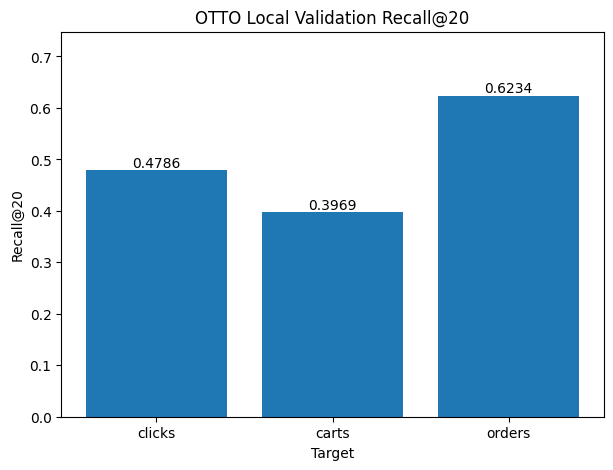

In [101]:
import matplotlib.pyplot as plt

plot_df = result_df[result_df["type"].isin(["clicks", "carts", "orders"])]

plt.figure(figsize=(7, 5))
plt.bar(plot_df["type"], plot_df["recall@20"])

plt.xlabel("Target")
plt.ylabel("Recall@20")
plt.title("OTTO Local Validation Recall@20")
plt.ylim(0, max(plot_df["recall@20"]) * 1.2)

for i, v in enumerate(plot_df["recall@20"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.savefig("/kaggle/working/otto_recall_at20.png", dpi=150, bbox_inches="tight")
plt.show()

In [102]:
!du -sh /kaggle/working/covisit || true
!du -sh /kaggle/working/splitted_raw_data || true
!du -sh /kaggle/working/candidate_data_top50 || true
!du -sh /kaggle/working/all_features || true
!du -sh /kaggle/working/candidated_features_top50 || true
!du -sh /kaggle/working/models_top50 || true
!du -sh /kaggle/working/predictions_top50 || true
!ls -lh /kaggle/working | grep otto || true

310M	/kaggle/working/covisit
493M	/kaggle/working/splitted_raw_data
262M	/kaggle/working/candidate_data_top50
91M	/kaggle/working/all_features
2.0G	/kaggle/working/candidated_features_top50
19M	/kaggle/working/models_top50
407M	/kaggle/working/predictions_top50
-rw-r--r-- 1 root root  302 Jun 29 11:15 otto_local_recall_result.csv
-rw-r--r-- 1 root root  33K Jun 29 11:16 otto_recall_at20.png


In [103]:
import os

EXPORT_DIR = "/kaggle/working/otto_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 把最终结果复制到一个 export 目录
!cp -r /kaggle/working/covisit {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/splitted_raw_data {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/candidate_data_top50 {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/all_features {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/candidated_features_top50 {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/models_top50 {EXPORT_DIR}/ 2>/dev/null || true
!cp -r /kaggle/working/predictions_top50 {EXPORT_DIR}/ 2>/dev/null || true

!cp /kaggle/working/otto_local_recall_result.csv {EXPORT_DIR}/ 2>/dev/null || true
!cp /kaggle/working/otto_recall_at20.png {EXPORT_DIR}/ 2>/dev/null || true

# 压缩
!cd /kaggle/working && zip -r -q otto_repro_outputs.zip otto_export

!ls -lh /kaggle/working/otto_repro_outputs.zip

-rw-r--r-- 1 root root 2.8G Jun 29 11:24 /kaggle/working/otto_repro_outputs.zip


In [105]:
import os
from IPython.display import FileLink, display

os.chdir("/kaggle/working")
display(FileLink("otto_repro_outputs.zip"))

/kaggle/working/otto_repro_outputs.zip